In [84]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,Dataset

import torchaudio

import pandas as pd
from IPython.display import Audio
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix

In [2]:
device= 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
bundle = torchaudio.pipelines.WAV2VEC2_BASE
wav2vec = bundle.get_model().to(device)
for param in wav2vec.parameters():
    param.requires_grad = False

In [4]:
max_len= 48000#14773 
batch_size=32
sr=bundle.sample_rate

In [5]:
data= pd.read_csv('reciters.csv')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3606 entries, 0 to 3605
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   surah          3606 non-null   int64 
 1   ayah           3606 non-null   int64 
 2   path_of_audio  3606 non-null   object
 3   reciter_name   3606 non-null   object
 4   ayah_text      3606 non-null   object
dtypes: int64(2), object(3)
memory usage: 141.0+ KB


In [7]:
data.head()

,surah,ayah,path_of_audio,reciter_name,ayah_text
0,2,285,kaggle/working/Jennifer_Grout_mp3/Jennifer_Gro...,Jennifer_Grout,آمَنَ الرَّسُولُ بِمَا أُنزِلَ إِلَيْهِ مِن رّ...
1,2,286,kaggle/working/Jennifer_Grout_mp3/Jennifer_Gro...,Jennifer_Grout,لَا يُكَلِّفُ اللَّهُ نَفْسًا إِلَّا وُسْعَهَا...
2,18,1,kaggle/working/Sulalatun_Nimah_mp3/Sulalatun_N...,Sulalatun_Nimah,بِسْمِ اللَّهِ الرَّحْمَـٰنِ الرَّحِيمِ الْحَم...
3,18,2,kaggle/working/Sulalatun_Nimah_mp3/Sulalatun_N...,Sulalatun_Nimah,قَيِّمًا لِّيُنذِرَ بَأْسًا شَدِيدًا مِّن لَّد...
4,18,3,kaggle/working/Sulalatun_Nimah_mp3/Sulalatun_N...,Sulalatun_Nimah,مَّاكِثِينَ فِيهِ أَبَدًا


In [8]:
encoder= LabelEncoder()


data['reciter_name']= encoder.fit_transform(data['reciter_name'])

In [9]:
classes= encoder.classes_

print(classes)

['Ayu_Rumiyati' 'Hudhaify' 'Husary' 'Jennifer_Grout' 'Minshawy'
 'Sulalatun_Nimah']


In [10]:
data.head()

,surah,ayah,path_of_audio,reciter_name,ayah_text
0,2,285,kaggle/working/Jennifer_Grout_mp3/Jennifer_Gro...,3,آمَنَ الرَّسُولُ بِمَا أُنزِلَ إِلَيْهِ مِن رّ...
1,2,286,kaggle/working/Jennifer_Grout_mp3/Jennifer_Gro...,3,لَا يُكَلِّفُ اللَّهُ نَفْسًا إِلَّا وُسْعَهَا...
2,18,1,kaggle/working/Sulalatun_Nimah_mp3/Sulalatun_N...,5,بِسْمِ اللَّهِ الرَّحْمَـٰنِ الرَّحِيمِ الْحَم...
3,18,2,kaggle/working/Sulalatun_Nimah_mp3/Sulalatun_N...,5,قَيِّمًا لِّيُنذِرَ بَأْسًا شَدِيدًا مِّن لَّد...
4,18,3,kaggle/working/Sulalatun_Nimah_mp3/Sulalatun_N...,5,مَّاكِثِينَ فِيهِ أَبَدًا


In [11]:
train_data , test_data = train_test_split(data.values,test_size=0.2,shuffle=True)

In [12]:
train_data.shape , test_data.shape

((2884, 5), (722, 5))

In [13]:
def pad_or_truncate(audio, target_length):
    """
    Pad or truncate audio to target_length samples
    Returns a tensor of shape (target_length,) or (1, target_length) if needed
    """
    if audio.dim() > 1:
        audio = audio.squeeze()  # Remove extra dimensions if present
    
    if audio.shape[-1] > target_length:
        # Truncate
        return audio[:target_length]
    else:
        # Pad
        padding = target_length - audio.shape[-1]
        # Pad only the last dimension
        return F.pad(audio, (0, padding))

In [14]:
class AudioDataset(Dataset):
    def __init__(self,data:pd.DataFrame):
        super().__init__()
        self.data= data

    def __getitem__(self, index):
        wave, sr = torchaudio.load(self.data[index][2])
        if sr != bundle.sample_rate:
            resampler = torchaudio.transforms.Resample(sr, int(bundle.sample_rate))
            wave = resampler(wave)

        # Convert to mono
        if wave.shape[0] > 1:
            wave = wave.mean(dim=0)
        else:
            wave = wave.squeeze(0)
        return pad_or_truncate(wave,max_len), self.data[index][3]
    
    def __len__(self):
        return len(self.data)

In [15]:
train_ds= AudioDataset(train_data)

test_ds= AudioDataset(test_data)

In [16]:
train_dl= DataLoader(train_ds,shuffle=True,batch_size=32)

test_dl = DataLoader(test_ds,batch_size=32)

In [92]:
_,(wave , label) = next(enumerate(train_dl))

print(wave[0].shape)

print(sr)

Audio(data= wave[0].numpy(),rate= sr)

torch.Size([48000])
16000


In [18]:
class ReciterClassification(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.cnn = wav2vec

      
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, len(classes))
        )

    def __call__(self,x):
        with torch.no_grad():
            x ,_= self.cnn(x)
        x= x.mean(dim=1)
        x= self.classifier(x)
        return x

In [19]:
model= ReciterClassification().to(device)

In [20]:
state_dic= torch.load('reciters_model.pth')

model.load_state_dict(state_dict=state_dic)

<All keys matched successfully>

In [21]:
model.state_dict

<bound method Module.state_dict of ReciterClassification(
  (cnn): Wav2Vec2Model(
    (feature_extractor): FeatureExtractor(
      (conv_layers): ModuleList(
        (0): ConvLayerBlock(
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        )
        (1-4): 4 x ConvLayerBlock(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        )
        (5-6): 2 x ConvLayerBlock(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        )
      )
    )
    (encoder): Encoder(
      (feature_projection): FeatureProjection(
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (projection): Linear(in_features=512, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (transformer): Transformer(
        (pos_conv_embed): ConvolutionalPositionalEmbedding(
          (conv): Paramet

In [22]:
_,(wave , label) = next(enumerate(train_dl))

pred= model(wave.to(device))

In [23]:
print(pred.argmax(dim=1))

tensor([2, 2, 4, 1, 2, 4, 2, 1, 1, 4, 2, 1, 0, 1, 2, 1, 2, 2, 5, 4, 4, 1, 1, 2,
        4, 2, 1, 4, 1, 4, 1, 5], device='cuda:0')


In [24]:
loss_fn= nn.CrossEntropyLoss()

optimizer= torch.optim.Adam(params=model.parameters(),lr=0.001) 

In [25]:
epochs=2

best_model_loss=float('inf')

for epoch in range(epochs):

    train_loss= 0
    test_loss = 0

    train_acc = 0
    test_acc  = 0

    model.train()

    for x_train, y_train in train_dl:

        x_train= x_train.to(device)
        y_train= y_train.to(device)

        prods = model(x_train)

        loss= loss_fn(prods,y_train)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
        
        train_loss+= loss.item()

        train_acc += (y_train==prods.argmax(dim=1)).float().mean().item()

    train_acc/= len(train_dl)
    train_loss/= len(train_dl)

    model.eval()

    with torch.inference_mode():

        for x_test , y_test in test_dl:
            
            x_test= x_test.to(device)
            y_test= y_test.to(device)

            prods= model(x_test)

            test_loss+= loss_fn(prods,y_test).item()

            test_acc += (y_test==prods.argmax(dim=1)).float().mean().item()

        test_acc/= len(test_dl)
        test_loss/= len(test_dl)
         
        if(test_loss<best_model_loss):
            torch.save(model.state_dict(),'reciters_model.pth')


    print(f'epoch : {epoch+1} , train_loss= {train_loss:.5f} , train_acc = {train_acc:.5f} |||| test_loss = {test_loss:.5f} , test_acc = {test_acc:.5f}')

/home/mahmoud-bannan/miniconda3/envs/torch_mnb/lib/python3.9/site-packages/torch/nn/modules/conv.py:306: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv1d(input, weight, bias, self.stride,


epoch : 1 , train_loss= 0.09301 , train_acc = 0.96806 |||| test_loss = 0.05199 , test_acc = 0.98671
epoch : 2 , train_loss= 0.09640 , train_acc = 0.98111 |||| test_loss = 0.04559 , test_acc = 0.98536


In [89]:
y_true =[]
y_pred  =[]

with torch.inference_mode():
    for x_test , y_test in test_dl:
            
        x_test= x_test.to(device)

        prods= model(x_test)      

        y_true.append(y_test.numpy())
        y_pred.append(prods.argmax(dim=1).cpu().numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

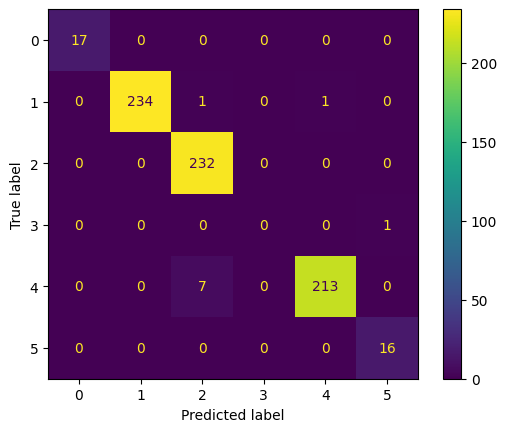

In [90]:
cm= confusion_matrix(y_true=y_true,y_pred=y_pred)
ConfusionMatrixDisplay(cm).plot()